# NATT: Neural attentive tabular additive model

NATT models numerical features with separate subnetworks while categorical tokens are contextualized by a transformer and mapped to additive contributions.


## Model in one view


$$
\eta(x)=\beta_0+\sum_{j\in\mathrm{num}}f_j(x_j)
+g\!\left(\operatorname{Transformer}(E(x_{\mathrm{cat}}))\right)
+\sum_{S\in\mathcal I}f_S(x_S).
$$



NATT treats numerical and categorical inputs differently. Numerical variables
retain separate shape subnetworks, while categorical embeddings are processed
as tokens by self-attention. Attention lets a categorical contribution depend
on the context supplied by other categorical tokens.

The numerical part is strictly feature-additive; the contextual categorical
part is decomposed into reported token contributions but is not a set of
context-free univariate functions. Head count, embedding dimension, and depth
control contextual capacity and must satisfy the usual transformer dimension
constraints.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


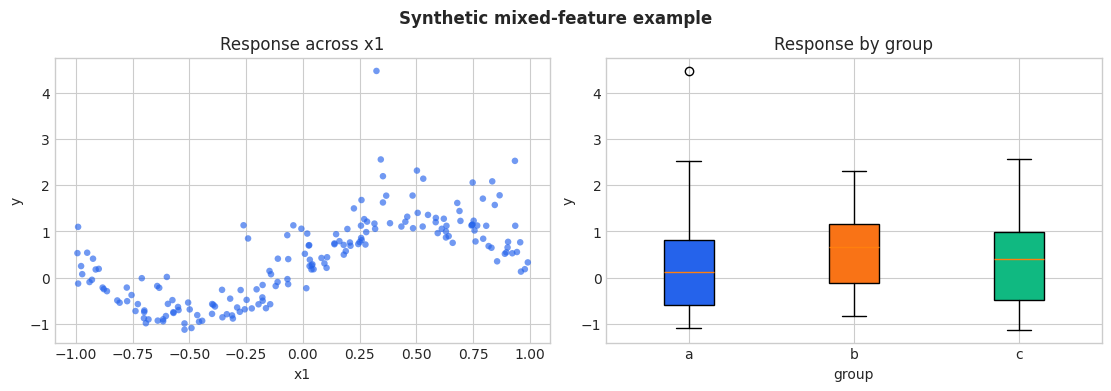

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import NATTLSS, NATTClassifier, NATTRegressor


model = NATTRegressor(
    d_model=16,
    n_layers=2,
    n_heads=2,
    transformer_dim_feedforward=32,
    head_layer_sizes=(16,),
    layer_sizes=[16, 8],
    attn_dropout=0.0,
)
model.get_params(deep=False)


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'activation': ReLU(),
 'attn_dropout': 0.0,
 'batch_norm': False,
 'bias': True,
 'cat_encoding': 'int',
 'd_model': 16,
 'dropout': 0.1,
 'embedding_activation': Identity(),
 'feature_dropout': 0.0,
 'ff_dropout': 0.1,
 'head_activation': SELU(),
 'head_dropout': 0.5,
 'head_layer_sizes': (16,),
 'head_skip_layers': False,
 'head_use_batch_norm': False,
 'interaction_degree': None,
 'interactions': None,
 'intercept': True,
 'layer_norm': False,
 'layer_norm_after_embedding': False,
 'layer_norm_eps': 1e-05,
 'layer_sizes': [16, 8],
 'lr': 0.0001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'n_heads': 2,
 'n_layers': 2,
 'norm': 'LayerNorm',
 'norm_first': True,
 'pooling_method': 'avg',
 'skip_connections': False,
 'skip_layers': False,
 'transformer_activation': ReLU(),
 'transformer_dim_feedforward': 32,
 'use_cls': True,
 'use_glu': False,
 'weight_decay': 1e-06,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'ple',
 'categorical_preprocessing': 'int',
 'u

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


/home/ad32/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


`Trainer.fit` stopped: `max_epochs=3` reached.


{'R2': 0.0905439089431671, 'Mean Squared Error': 0.6347168306885222}

,term,term_type,output,importance
0,group,main,0,0.306859
1,x1,main,0,0.083232
2,x2,main,0,0.037313


,term,term_type,output,value,contribution,count,importance
0,x1,main,0,-0.965,-0.119274,2,0.083232
1,x1,main,0,-0.8895,-0.116271,2,0.083232
2,x1,main,0,-0.7905,-0.116037,2,0.083232
3,x1,main,0,-0.6915,-0.108874,2,0.083232
4,x1,main,0,-0.58,-0.106983,2,0.083232
5,x1,main,0,-0.4875,-0.104832,2,0.083232
6,x1,main,0,-0.35,-0.099381,1,0.083232
7,x1,main,0,-0.209,-0.096429,2,0.083232
8,x1,main,0,-0.12505,-0.073754,2,0.083232
9,x1,main,0,-0.05205,-0.044209,2,0.083232


## Evaluate and explain


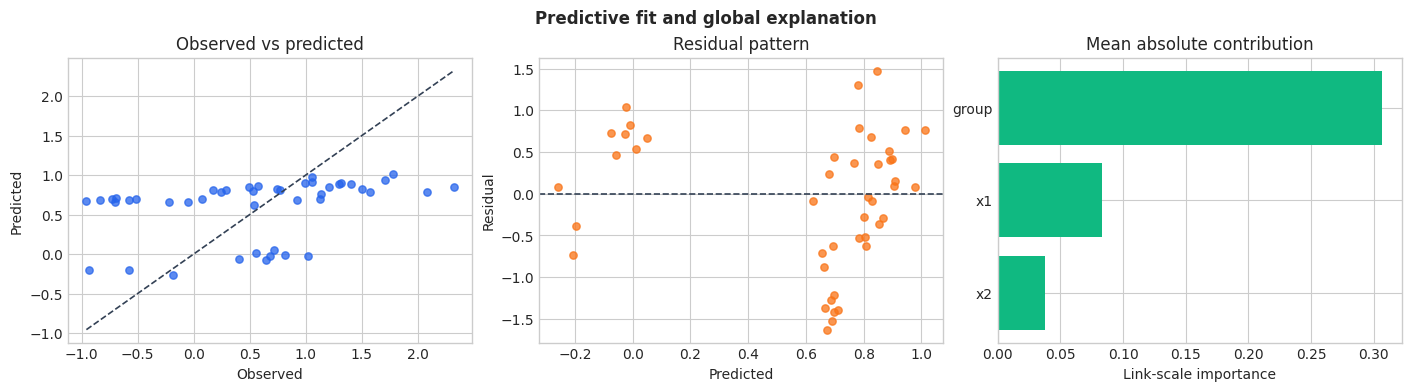

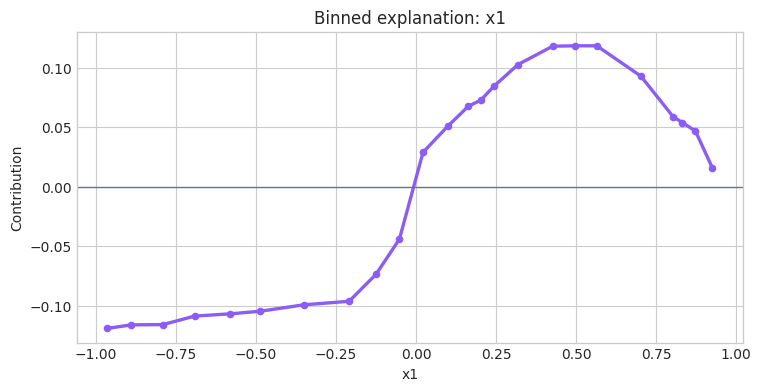

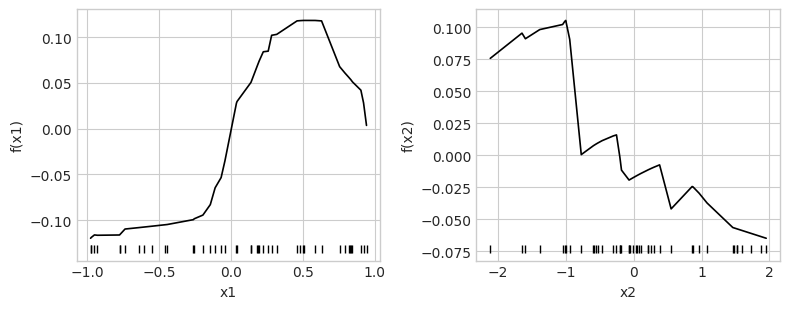

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

`d_model`, `n_heads`, and `n_layers` control categorical attention; `layer_sizes` controls independent numerical shape networks.


{'x1': (45, 1), 'x2': (45, 1), 'group': (45, 1)}

[<Figure size 800x320 with 2 Axes>]

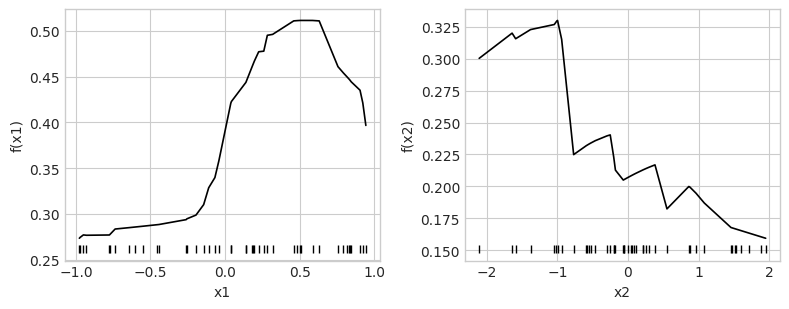

In [6]:
terms = model.predict_components(X_test).terms
display({name: value.shape for name, value in terms.items()})
model.plot_terms(X_test, pages=1)


## Supported task variants

NATT supports regression, classification, and LSS objectives.


In [7]:
task_variants = {"regression": NATTRegressor(), "classification": NATTClassifier(), "distributional": NATTLSS()}


## References

- [Neural Attentive Tabular Transformer](https://openreview.net/forum?id=TdJ7lpzAkD).
